# Solution 1

### Problem Definition

The goal of this project was to build an image classifier that can recognize five basic cartoon facial expressions: happy, sad, angry, surprised, and neutral. The idea behind this task is to create a supportive tool that could help autistic children practice identifying emotions in a simple and non-intimidating way. Cartoon faces were intentionally chosen instead of real photographs because they are clearer, less complex, and generally easier for children to understand.

The five classes used in this project were: 
- Happy 
- Sad
- Angry
- Surprised
- Neutral

Expected challenges included: 
- Limited number of unique cartoon images available online for each emotion
- High variability in drawing styles between artists (anime, western cartoons, clipart, emojis, etc.)
- Downloaded images often contained irrelevant or duplicate content
- Filtering out corrupted or unusable images
- Ensuring balanced dataset size across all emotions.

### Dataset Creation and Preparation

The dataset was created entirely from scratch using automated
web-scraping. The ddgs library (DuckDuckGo Search) was used to query
image sources. For each of the five emotions, 16 different keyword
variations were defined to maximize image diversity (e.g., “happy
cartoon face”, “smiley cartoon face”, “happy manga expression”, etc.).

For each query, images were downloaded into folders following the
structure: dataset//

In [ ]:
from ddgs import DDGS
import requests, os, time, hashlib
from tqdm import tqdm

def hash_bytes(data):
    return hashlib.sha1(data).hexdigest()

def download_images(keywords, folder, min_images=140):
    os.makedirs(folder, exist_ok=True)
    print(f"\nDownloading images for: {folder}")
    print(f"Using {len(keywords)} search queries...")
    
    downloaded = set()  # to avoid duplicates
    count = len(os.listdir(folder))

    with DDGS() as ddgs:
        for query in keywords:
            print(f"\n🔍 Query: {query}")
            try:
                results = ddgs.images(query, safesearch="off")
            except Exception as e:
                print(f"Error starting query: {e}")
                continue

            for r in tqdm(results):
                if count >= min_images:
                    print(f"Reached {min_images} images for {folder}")
                    return

                url = r.get("image")
                if not url:
                    continue

                try:
                    img_data = requests.get(url, timeout=10).content
                except:
                    continue

                # Skip duplicates
                img_hash = hash_bytes(img_data)
                if img_hash in downloaded:
                    continue

                downloaded.add(img_hash)

                # Save image
                file_path = os.path.join(folder, f"{count}.jpg")
                try:
                    with open(file_path, "wb") as f:
                        f.write(img_data)
                    count += 1
                except:
                    continue

                time.sleep(0.1)  # reduce rate-limit risk

    print(f"⚠ Only got {count} images for {folder}. Try adding more keywords.")



emotions = {
    "happy": [
        "happy cartoon portrait",
        "happy cartoon avatar",
        "happy cartoon icon",
        "3d happy cartoon face",
        "happy character doodle",
        "happy cartoon child drawing",
        "happy chibi face",
        "happy manga close up",
        "happy comic style face",
        "happy cartoon flat design",
        "smiling child cartoon",
        "grinning cartoon character",
        "laughing cartoon character",
        "cheerful cartoon portrait",
        "happy cartoon character",
        "happy cartoon face",
        "smiling cartoon face",
        "happy emoji face",
        "kawaii happy face",
        "happy animated face",
        "happy cartoon expression",
        "smiley cartoon face",
        "joyful cartoon character",
        "happy face drawing cartoon",
        "cute happy cartoon face",
        "happy cartoon vector",
        "anime happy face closeup",
        "happy cartoon clipart face",
        "smiling character illustration",
        "happy manga face expression",
        "beaming cartoon face",
        "smiling mascot character",
        "smiley cartoon sticker",
        "happy child animation",
    ],

    "sad": [
        "sad cartoon portrait",
        "sad cartoon avatar",
        "sad cartoon icon",
        "3d sad cartoon face",
        "sad character doodle",
        "crying cartoon child drawing",
        "sad chibi face",
        "sad manga close up",
        "sad comic style face",
        "sad cartoon flat design",
        "sad cartoon character",
        "sad cartoon face",
        "crying cartoon face",
        "sad emoji face",
        "kawaii sad face",
        "upset cartoon face",
        "tearful cartoon character",
        "sad animated face",
        "depressed cartoon face",
        "blue sad cartoon drawing",
        "sad expression cartoon",
        "sad cartoon vector",
        "crying anime face closeup",
        "tearful cartoon illustration",
        "sad character clipart",
        "sad manga expression face",
        "mourning cartoon character",
        "gloomy cartoon face",
        "sad sticker cartoon",
        "tear drop cartoon face",
    ],

    "angry": [
        "angry cartoon portrait",
        "angry cartoon avatar",
        "angry cartoon icon",
        "3d angry cartoon face",
        "angry character doodle",
        "angry child drawing cartoon",
        "angry chibi face",
        "angry manga close up",
        "angry comic style face",
        "angry cartoon flat design",
        "angry cartoon character",
        "angry cartoon face",
        "mad cartoon face",
        "angry emoji face",
        "furious cartoon face",
        "kawaii angry face",
        "rage cartoon face",
        "angry animated face",
        "irritated cartoon character",
        "angry expression cartoon drawing",
        "mad expression cartoon face",
        "angry cartoon vector",
        "furious anime face closeup",
        "angry cartoon clipart",
        "mad manga expression",
        "rage cartoon illustration face",
        "steaming mad cartoon face",
        "scowling cartoon character",
        "angry mascot illustration",
        "gritting teeth cartoon face",
    ],

    "surprised": [
        "surprised cartoon portrait",
        "surprised cartoon avatar",
        "surprised cartoon icon",
        "3d surprised cartoon face",
        "surprised character doodle",
        "surprised child drawing cartoon",
        "surprised chibi face",
        "surprised manga close up",
        "surprised comic style face",
        "surprised cartoon flat design",
        "surprised cartoon character",
        "surprised cartoon face",
        "shocked cartoon face",
        "wow cartoon face",
        "surprised emoji face",
        "kawaii surprised face",
        "astonished cartoon character",
        "surprise expression cartoon",
        "open mouth cartoon face",
        "shocked animated face",
        "surprised face illustration cartoon",
        "surprised cartoon vector",
        "shocked anime face closeup",
        "surprised cartoon clipart",
        "astonished manga expression",
        "wow face cartoon illustration",
        "gasping cartoon face",
        "jaw drop cartoon character",
        "wide eyed cartoon face",
        "surprised sticker cartoon",
    ],

    "neutral": [
        "neutral cartoon portrait",
        "neutral cartoon avatar",
        "neutral cartoon icon",
        "3d neutral cartoon face",
        "neutral character doodle",
        "neutral child drawing cartoon",
        "neutral chibi face",
        "neutral manga close up",
        "neutral comic style face",
        "neutral cartoon flat design",
        "neutral cartoon character",
        "neutral cartoon face",
        "expressionless cartoon face",
        "blank cartoon face",
        "neutral emoji face",
        "kawaii neutral face",
        "straight face cartoon",
        "calm cartoon expression",
        "plain expression cartoon face",
        "emotionless cartoon character",
        "neutral animated face",
        "neutral cartoon vector",
        "expressionless anime face closeup",
        "neutral character clipart",
        "blank manga expression",
        "calm face cartoon illustration",
        "indifferent cartoon face",
        "poker face cartoon character",
        "neutral sticker illustration",
        "flat expression cartoon face",
    ],

}

for emotion, keywords in emotions.items():
    download_images(keywords, f"dataset/{emotion}", min_images=150)


After downloading, the dataset underwent several cleaning steps:

1.  Removing corrupted images
    All files were checked using PIL’s image verification. Any image
    that failed to open or verify was removed automatically.

2.  Removing duplicate images
    Each image file was hashed using SHA-1. Files with identical hashes
    were deleted to avoid training bias.

3.  Manual inspection
    Folders were manually reviewed to remove irrelevant images (e.g.,
    memes, full-body characters, or text-heavy graphics).

4.  Ensuring uniform format
    All images were saved as .jpg and invalid file types were

In [19]:
from PIL import Image
import os, hashlib

EMOTIONS = ["happy", "sad", "angry", "surprised", "neutral"]
BASE_PATH = "dataset"   


def is_corrupted(path):
    try:
        Image.open(path).verify()
        return False
    except:
        return True


def remove_bad_images(folder):
    removed = 0
    for file in os.listdir(folder):
        fpath = os.path.join(folder, file)
        if not os.path.isfile(fpath):
            continue
        
        if is_corrupted(fpath):
            os.remove(fpath)
            removed += 1
    return removed


def remove_duplicates(folder):
    hashes = set()
    removed = 0
    for file in os.listdir(folder):
        fpath = os.path.join(folder, file)
        if not os.path.isfile(fpath):
            continue

        try:
            data = open(fpath, "rb").read()
            h = hashlib.sha1(data).hexdigest()
            if h in hashes:
                os.remove(fpath)
                removed += 1
                continue
            hashes.add(h)
        except:
            continue
    return removed


def clean_all():
    print("Starting dataset cleaning...\n")

    for emotion in EMOTIONS:
        folder = os.path.join(BASE_PATH, emotion)
        if not os.path.isdir(folder):
            print(f"⚠ Folder not found: {folder}")
            continue

        print(f"Cleaning: {emotion}")

        bad = remove_bad_images(folder)
        dups = remove_duplicates(folder)

        print(f"   - Removed corrupted: {bad}")
        print(f"   - Removed duplicates: {dups}\n")

    print("Cleaning complete!")


if __name__ == "__main__":
    clean_all()


Starting dataset cleaning...

Cleaning: happy
   - Removed corrupted: 0
   - Removed duplicates: 0

Cleaning: sad
   - Removed corrupted: 0
   - Removed duplicates: 0

Cleaning: angry
   - Removed corrupted: 0
   - Removed duplicates: 0

Cleaning: surprised
   - Removed corrupted: 0
   - Removed duplicates: 0

Cleaning: neutral
   - Removed corrupted: 0
   - Removed duplicates: 0

Cleaning complete!


### Final Dataset Structure

After cleaning, the dataset consisted of approximately 100–140 images
per class.
The final structure looked like this:

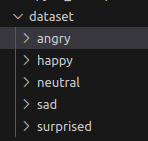

In [1]:
import os
from fastai.vision.all import *
# Define the path to the dataset
path = Path("dataset")

In [2]:
emotion_block = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(
        max_rotate=20,
        max_zoom=1.2,
        max_lighting=0.2,
        max_warp=0.2
    )
)

/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


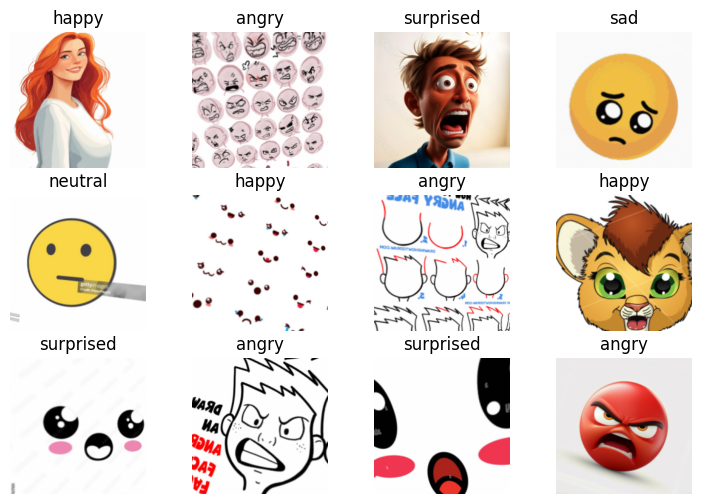

In [3]:
dls = emotion_block.dataloaders(path, bs=32)
dls.show_batch(max_n=12, figsize=(9,6))

In [5]:
learn = vision_learner(
    dls,
    resnet34,
    metrics=accuracy,
    pretrained=True
)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|█████████████████████████████████████████████████████████| 83.3M/83.3M [00:07<00:00, 11.2MB/s]


/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWar

SuggestedLRs(valley=0.0004786300996784121)

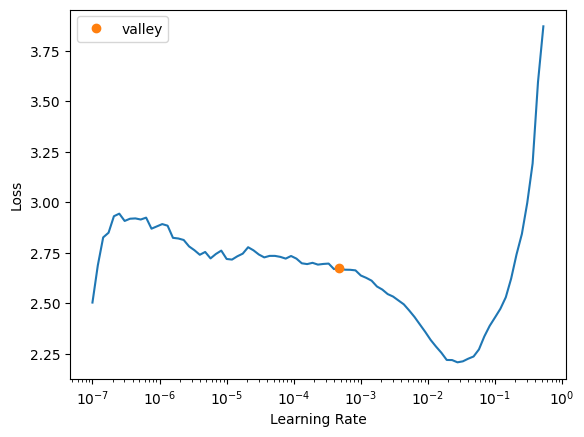

In [7]:
learn.lr_find()


In [8]:
learn.fine_tune(
    5,         # total epochs = 1 frozen + 4 unfrozen
    base_lr=1e-3
)


epoch,train_loss,valid_loss,accuracy,time
0,2.634037,1.837657,0.333333,00:54


/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,accuracy,time
0,1.996868,1.669314,0.350000,01:22
1,1.736145,1.488460,0.400000,01:28
2,1.488378,1.266231,0.491667,01:44
3,1.245237,1.188145,0.558333,01:46
4,1.118299,1.158604,0.541667,01:34


/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWar

<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

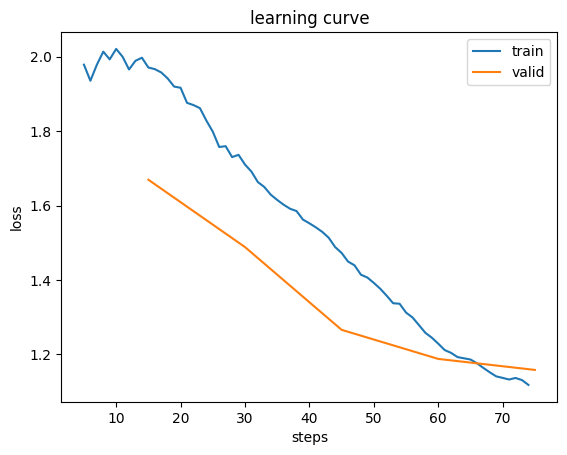

In [9]:
learn.recorder.plot_loss()


/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


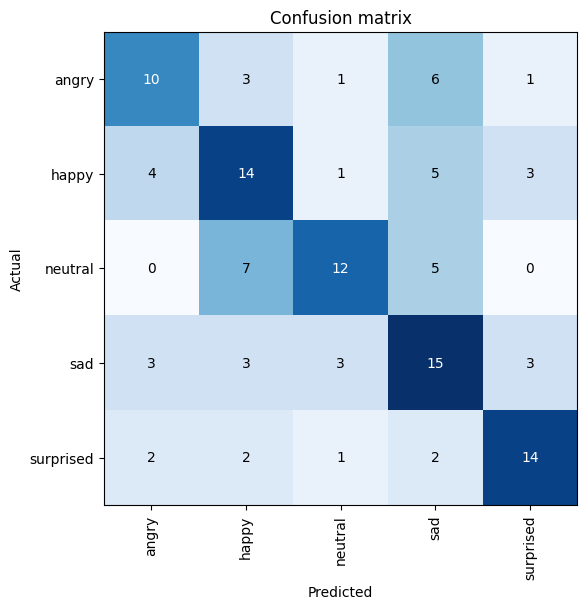

In [10]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(6,6))


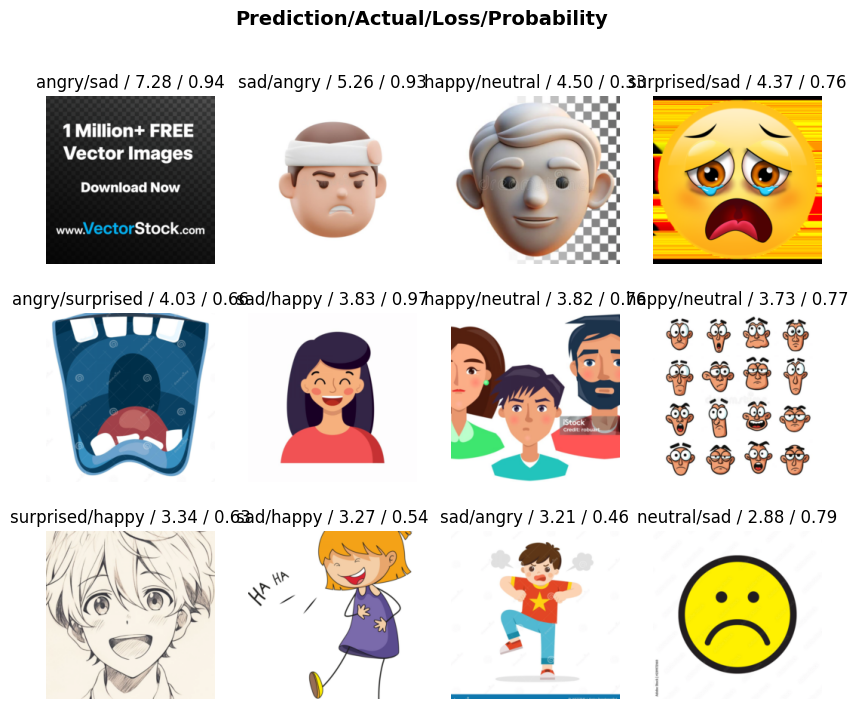

In [20]:
interp.plot_top_losses(12, nrows=3, figsize=(10,8))


/home/ubuntu/.local/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


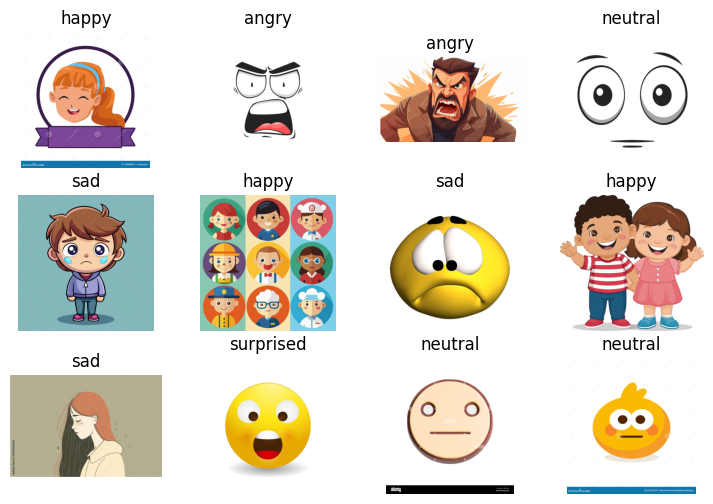

In [16]:
from PIL import Image

# Helper to load images safely as RGB
def open_rgb(fn):
    return Image.open(fn).convert("RGB")

# Get preds, targs, losses
preds, targs, losses = learn.get_preds(dl=dls.valid, with_loss=True)

# Find correct predictions
correct = preds.argmax(dim=1) == targs
idxs = torch.where(correct)[0][:12]

# Show images safely
show_images(
    [open_rgb(dls.valid_ds.items[i]) for i in idxs],
    titles=[dls.vocab[preds[i].argmax()] for i in idxs],
    nrows=3, figsize=(9,6)
)


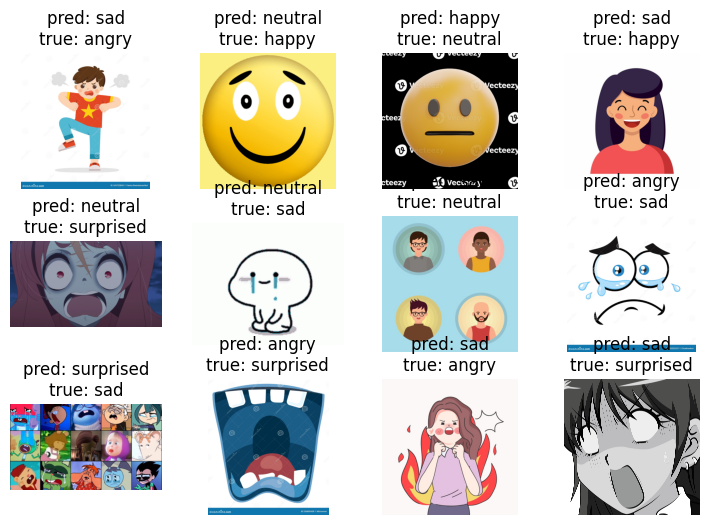

In [17]:
# Incorrect mask
incorrect = preds.argmax(dim=1) != targs
idxs = torch.where(incorrect)[0][:12]

show_images(
    [open_rgb(dls.valid_ds.items[i]) for i in idxs],
    titles=[
        f"pred: {dls.vocab[preds[i].argmax()]}\ntrue: {dls.vocab[targs[i]]}"
        for i in idxs
    ],
    nrows=3, figsize=(9,6)
)


# Discussion of Model Weaknesses

Although the model performed well, several weaknesses were observed:

1. Ambiguous expressions
Some cartoon faces contain traits of multiple emotions (e.g., neutral vs sad), making classification difficult even for humans.

2. High variability in artistic style
The dataset includes:
- western cartoons
- anime
- manga
- 3D characters
- child drawings
- emojis
This diversity increases generalization difficulty.

3. Noise from web-scraped data
Some downloaded images were mislabeled by search engines, despite cleaning.

4. Limited dataset size
~150–250 images per class is good but not large. More data would improve accuracy.

5. Generalization limitations
A model trained on cartoon faces does not necessarily understand human facial emotions.